<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

<div style="text-align: center;">

# المپیاد هوش مصنوعی | آزمون عملی جامع | تابستان ۱۴۰۵

</div>

**به نام خدا**

- مدت آزمون: **۲۴۰ دقیقه**
- مجموع نمره: **۱۵۰**
- این آزمون شش مسئلهٔ مستقل دارد؛ می‌توانید به هر ترتیبی که می‌خواهید حل کنید.
- در سلول‌های `# TODO` کد خود را بنویسید. سلول‌های علامت‌گذاری‌شده با «فقط اجرا کنید» (read-only) را تغییر ندهید.
- فقط از `numpy`، `matplotlib` و `torch` استفاده کنید (و `sklearn` صرفاً در جایی که صریحاً مجاز اعلام شده است).
- برای نمرهٔ کامل، کد باید بدون خطا اجرا شود و نتایج خواسته‌شده را تولید کند. توضیح کوتاه فارسی در انتهای هر مسئله دربارهٔ مشاهده‌هایتان بنویسید.
- ارزیابی هر بخش در انتهای همان بخش با `assert` یا سلول بررسی انجام می‌شود؛ مطمئن شوید همهٔ سلول‌ها بدون خطا (بدون `AssertionError`) اجرا می‌شوند.

</div>

<style>
.katex, .katex-display, .katex-html, .katex-mathml { direction: ltr !important; unicode-bidi: isolate; }
div[dir="ltr"] { text-align: center; }
</style>


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

## ۰. آماده‌سازی

سلول زیر را اجرا کنید:

</div>

In [1]:
# آماده‌سازی — فقط اجرا کنید، تغییر ندهید
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 1405
np.random.seed(SEED)
torch.manual_seed(SEED)
plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['figure.dpi'] = 100
print("numpy:", np.__version__, "| torch:", torch.__version__)

numpy: 2.2.6 | torch: 2.13.0+cu130


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

## مسئلهٔ ۱ — رگرسیون لجستیک با regularization L2 از صفر (۲۵ نمره)

می‌خواهیم رگرسیون لجستیک را **بدون استفاده از کتابخانه‌های یادگیری ماشین** پیاده کنیم. مدل به‌ازای ورودی ⁦$x \in \mathbb{R}^2$⁩ و پارامترهای ⁦$w \in \mathbb{R}^2$⁩، ⁦$b \in \mathbb{R}$⁩:

<div dir="ltr">

$$
\hat{p}(x) = \sigma(w^\top x + b), \qquad \sigma(z) = \frac{1}{1+e^{-z}}
$$

</div>

تابع هزینه با regularization L2 (بدون رگولاریز کردن بایاس):

<div dir="ltr">

$$
J(w, b) = -\frac{1}{n}\sum_{i=1}^{n}\Big[y_i \ln \hat{p}(x_i) + (1-y_i)\ln(1-\hat{p}(x_i))\Big] + \frac{\lambda}{2n}\|w\|^2
$$

</div>

دادهٔ مسئله (دو خوشهٔ گاوسی هم‌پوشان) در سلول زیر ساخته می‌شود.

</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

</div>

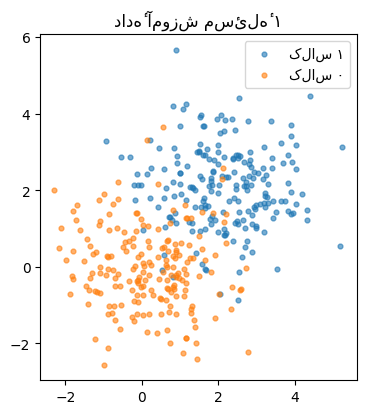

In [2]:
# ساخت داده — فقط اجرا کنید، تغییر ندهید
rng = np.random.default_rng(SEED)
n_per_class = 300
X1 = rng.normal(loc=[2.0, 2.0], scale=1.1, size=(n_per_class, 2))
X0 = rng.normal(loc=[0.0, 0.0], scale=1.1, size=(n_per_class, 2))
X_t1 = np.vstack([X1, X0]).astype(np.float64)          # (600, 2)
y_t1 = np.hstack([np.ones(n_per_class), np.zeros(n_per_class)]).astype(np.float64)

# تقسیم آموزش/آزمون
idx = rng.permutation(len(X_t1))
n_tr = 400
tr, te = idx[:n_tr], idx[n_tr:]
X1_tr, y1_tr, X1_te, y1_te = X_t1[tr], y_t1[tr], X_t1[te], y_t1[te]

plt.scatter(X1_tr[y1_tr==1][:,0], X1_tr[y1_tr==1][:,1], s=12, alpha=0.6, label='کلاس ۱')
plt.scatter(X1_tr[y1_tr==0][:,0], X1_tr[y1_tr==0][:,1], s=12, alpha=0.6, label='کلاس ۰')
plt.legend(); plt.title('دادهٔ آموزش مسئلهٔ ۱'); plt.gca().set_aspect('equal')
plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

**۱-الف) (۶ نمره)** توابع `sigmoid(z)`، `cost(w, b, X, y, lam)` و `grads(w, b, X, y, lam)` را بنویسید. `cost` باید هزینهٔ ⁦$J$⁩ بالا و `grads` باید ⁦$\frac{\partial J}{\partial w}$⁩ و ⁦$\frac{\partial J}{\partial b}$⁩ را (به‌صورت دقیق، برداری) برگرداند. برای پایداری عددی از np.clip روی ورودی لگاریتم استفاده کنید (مثلاً در بازهٔ ⁦$[10^{-12}, 1-10^{-12}]$⁩).

**توجه:** گرادیان‌ها را خودتان به‌صورت تحلیلی استخراج کنید؛ درستی‌شان را با تفاضل متناهی در سلول بررسی تأیید کنید (سلول بررسی با مشتق عددی شما مقایسه می‌کند، نه با فرمول بسته).

</div>

In [3]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def cost(w, b, X, y, lam=0.0):
    n = len(y)
    p = sigmoid(X @ w + b)
    p = np.clip(p, 1e-12, 1 - 1e-12)
    ce = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
    return ce + (lam / (2 * n)) * (w @ w)

def grads(w, b, X, y, lam=0.0):
    n = len(y)
    p = sigmoid(X @ w + b)
    err = p - y
    grad_w = (X.T @ err) / n + (lam / n) * w
    grad_b = err.mean()
    return grad_w, grad_b

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

</div>

In [4]:
# بررسی تفاضل متناهی — فقط اجرا کنید؛ بدون خطا باید اجرا شود
w0 = np.array([0.3, -0.7]); b0 = 0.2; lam0 = 0.5
gw, gb = grads(w0, b0, X1_tr, y1_tr, lam0)
eps = 1e-6
for j in range(2):
    e = np.zeros(2); e[j] = eps
    num = (cost(w0 + e, b0, X1_tr, y1_tr, lam0) - cost(w0 - e, b0, X1_tr, y1_tr, lam0)) / (2 * eps)
    assert abs(num - gw[j]) < 1e-4, f"gradient mismatch in w[{j}]: {num} vs {gw[j]}"
num_b = (cost(w0, b0 + eps, X1_tr, y1_tr, lam0) - cost(w0, b0 - eps, X1_tr, y1_tr, lam0)) / (2 * eps)
assert abs(num_b - gb) < 1e-4, f"gradient mismatch in b: {num_b} vs {gb}"
print("همهٔ گرادیان‌ها با تفاضل متناهی سازگارند ✓")

همهٔ گرادیان‌ها با تفاضل متناهی سازگارند ✓


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

**۱-ب) (۷ نمره)** حلقهٔ آموزش `train_logreg(X, y, lam, lr, epochs)` را بنویسید: با ⁦$w=0$⁩، ⁦$b=0$⁩ شروع کنید و با gradient descent تمام‌دسته‌ای (full-batch) پارامترها را به‌روزرسانی کنید؛ تاریخچهٔ هزینه را برگردانید. سپس مدل را با ⁦$\lambda = 0$⁩ آموزش دهید، منحنی هزینه را رسم کنید و **دقت (accuracy)** روی دادهٔ آموزش و آزمون را گزارش کنید (آستانهٔ تصمیم ⁦$0.5$⁩).

</div>

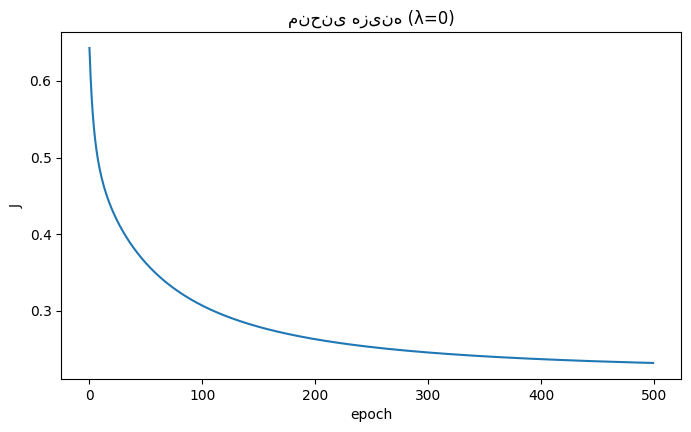

دقت آموزش: 0.9250 | دقت آزمون: 0.9000


In [5]:
def train_logreg(X, y, lam=0.0, lr=0.1, epochs=500):
    w = np.zeros(X.shape[1]); b = 0.0
    history = []
    for _ in range(epochs):
        gw, gb = grads(w, b, X, y, lam)
        w -= lr * gw; b -= lr * gb
        history.append(cost(w, b, X, y, lam))
    return w, b, history

def accuracy(w, b, X, y):
    return ((sigmoid(X @ w + b) >= 0.5) == (y == 1)).mean()

w1, b1, hist1 = train_logreg(X1_tr, y1_tr, lam=0.0)
plt.plot(hist1); plt.xlabel('epoch'); plt.ylabel('J'); plt.title('منحنی هزینه (λ=0)'); plt.show()
print(f"دقت آموزش: {accuracy(w1, b1, X1_tr, y1_tr):.4f} | دقت آزمون: {accuracy(w1, b1, X1_te, y1_te):.4f}")

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

**۱-ج) (۶ نمره)** اثر regularization: برای ⁦$\lambda \in \{0, 0.01, 0.1, 1, 10, 100\}$⁩ مدل را آموزش دهید و نمودار دقت آزمون بر حسب ⁦$\lambda$⁩ (محور لگاریتمی) را رسم کنید. کدام ⁦$\lambda$⁩ بهتر است؟ چه الگویی می‌بینید و چرا؟

</div>

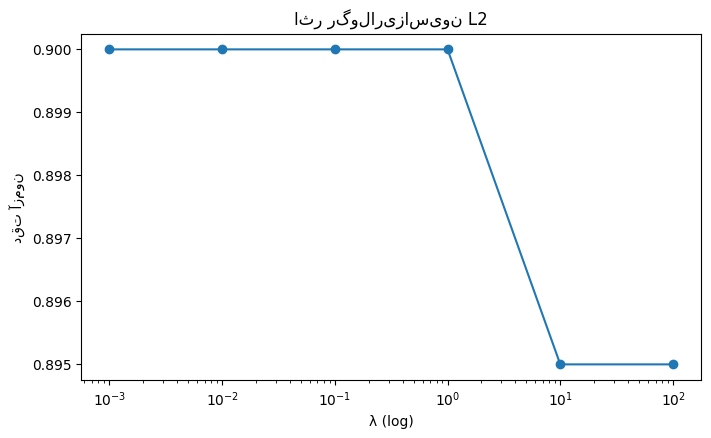

بهترین λ: 0 با دقت 0.9000


In [6]:
lams = [0, 0.01, 0.1, 1, 10, 100]
accs = []
for lam in lams:
    w_l, b_l, _ = train_logreg(X1_tr, y1_tr, lam=lam)
    accs.append(accuracy(w_l, b_l, X1_te, y1_te))
plt.semilogx([max(l, 1e-3) for l in lams], accs, 'o-')
plt.xlabel('λ (log)'); plt.ylabel('دقت آزمون'); plt.title('اثر رگولاریزاسیون L2'); plt.show()
best = lams[int(np.argmax(accs))]
print(f"بهترین λ: {best} با دقت {max(accs):.4f}")

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

**۱-د) (۶ نمره)** مرز تصمیم: مدل با بهترین ⁦$\lambda$⁩ را روی شبکهٔ نقاط ⁦$[-4,6]\times[-4,6]$⁩ ارزیابی کنید و مرز تصمیم ⁦$\sigma(w^\top x + b) = 0.5$⁩ را همراه با نقاط آزمون رسم کنید. سپس نشان دهید مرز تصمیم رگرسیون لجستیک همیشه **خطی** است؛ یعنی معادلهٔ صریح خط ⁦$w^\top x + b = 0$⁩ را برای مدل خودتان بنویسید و با رسم بررسی کنید که contour سطح ⁦$0.5$⁩ روی همین خط است.

</div>

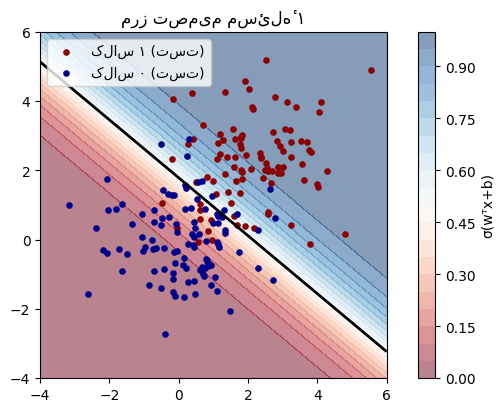

خط تصمیم: 1.162·x₁ + 1.390·x₂ + -2.483 = 0


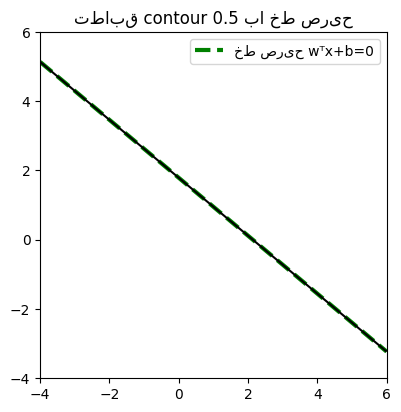

In [7]:
w_best, b_best, _ = train_logreg(X1_tr, y1_tr, lam=best)
xx, yy = np.meshgrid(np.linspace(-4, 6, 300), np.linspace(-4, 6, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = sigmoid(grid @ w_best + b_best).reshape(xx.shape)

plt.contourf(xx, yy, zz, levels=20, cmap='RdBu', alpha=0.5)
plt.colorbar(label='σ(wᵀx+b)')
plt.contour(xx, yy, zz, levels=[0.5], colors='k', linewidths=2)
plt.scatter(X1_te[y1_te==1][:,0], X1_te[y1_te==1][:,1], s=14, c='darkred', label='کلاس ۱ (تست)')
plt.scatter(X1_te[y1_te==0][:,0], X1_te[y1_te==0][:,1], s=14, c='darkblue', label='کلاس ۰ (تست)')
plt.legend(); plt.gca().set_aspect('equal'); plt.title('مرز تصمیم مسئلهٔ ۱'); plt.show()

# معادلهٔ صریح خط:  w1*x + w2*y + b = 0  →  y = -(w1*x + b)/w2
print(f"خط تصمیم: {w_best[0]:.3f}·x₁ + {w_best[1]:.3f}·x₂ + {b_best:.3f} = 0")
xs = np.linspace(-4, 6, 10)
plt.plot(xs, -(w_best[0] * xs + b_best) / w_best[1], 'g--', lw=3, label='خط صریح wᵀx+b=0')
plt.contour(xx, yy, zz, levels=[0.5], colors='k', linewidths=1.5)
plt.legend(); plt.gca().set_aspect('equal'); plt.title('تطابق contour 0.5 با خط صریح'); plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

**توضیح کوتاه (لازم برای نمره):** مشاهدات خود دربارهٔ روند هزینه، اثر ⁦$\lambda$⁩ و خطی بودن مرز تصمیم در یک سلول markdown بنویسید.

</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

**پاسخ:** هزینه به‌صورت صاف و یکنوا کاهش می‌یابد (تابع هزینهٔ لجستیک با regularization L2 محدب است). مقادیر کوچک λ تغییری در دقت نمی‌دهند و مقادیر خیلی بزرگ (λ=100) وزن‌ها را به‌شدت کوچک می‌کنند و مدل به سمت «همیشه کلاس اکثریت» می‌رود و دقت افت می‌کند. مرز تصمیم دقیقاً یک خط است چون σ یکنواست و تراز 0.5 آن روی wᵀx+b=0 می‌افتد.

</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

## مسئلهٔ ۲ — درخت تصمیم و bagging از صفر (۲۵ نمره)

درخت تصمیم رگرسیون/طبقه‌بندی را با معیار **Gini** پیاده می‌کنیم و سپس با **bagging** (Bootstrap AGGregatING) جمعش می‌کنیم. دادهٔ این مسئله یک مسئلهٔ طبقه‌بندی دوبعدی غیرخطی (چهار خوشهٔ گوشه‌ای) است.

</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

</div>

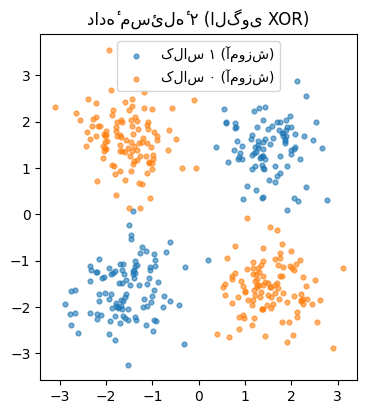

In [8]:
# ساخت داده — فقط اجرا کنید، تغییر ندهید
rng = np.random.default_rng(SEED + 1)
n_pc = 150
centers = np.array([[1.5, 1.5], [-1.5, -1.5], [1.5, -1.5], [-1.5, 1.5]])
labels_of_center = [1, 1, 0, 0]   # XOR-like
Xs, ys = [], []
for c, lab in zip(centers, labels_of_center):
    Xs.append(rng.normal(loc=c, scale=0.55, size=(n_pc, 2)))
    ys.append(np.full(n_pc, lab))
X_t2 = np.vstack(Xs); y_t2 = np.hstack(ys)
idx = rng.permutation(len(X_t2)); n_tr = 400
tr2, te2 = idx[:n_tr], idx[n_tr:]
X2_tr, y2_tr, X2_te, y2_te = X_t2[tr2], y_t2[tr2], X_t2[te2], y_t2[te2]

def plot_t2(title):
    plt.scatter(X2_tr[y2_tr==1][:,0], X2_tr[y2_tr==1][:,1], s=12, alpha=0.6, label='کلاس ۱ (آموزش)')
    plt.scatter(X2_tr[y2_tr==0][:,0], X2_tr[y2_tr==0][:,1], s=12, alpha=0.6, label='کلاس ۰ (آموزش)')
    plt.legend(); plt.title(title); plt.gca().set_aspect('equal')
plot_t2('دادهٔ مسئلهٔ ۲ (الگوی XOR)'); plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

**۲-الف) (۷ نمره)** تابع `gini(y)` را بنویسید که ناخالصی Gini برچسب‌های `y` را حساب کند: ⁦$G(y) = 1 - \sum_c p_c^2$⁩. سپس تابع `best_split(X, y)` را بنویسید که از میان همهٔ (ویژگی، آستانه)های ممکن، شکافی را بیابد که **کاهش وزنی ناخالصی** را بیشینه کند. برای آستانه‌ها کافی است میانگین جفت‌های متوالی مقادیر یکتای هر ویژگی را امتحان کنید. خروجی: `(feature, threshold, gain)`.

</div>

In [9]:
def gini(y):
    _, counts = np.unique(y, return_counts=True)
    p = counts / counts.sum()
    return 1.0 - (p ** 2).sum()

def best_split(X, y):
    n, d = X.shape
    parent = gini(y)
    best = (None, None, 0.0)   # feature, threshold, gain
    for j in range(d):
        vals = np.unique(X[:, j])
        thresholds = (vals[:-1] + vals[1:]) / 2.0
        for t in thresholds:
            left = y[X[:, j] <= t]; right = y[X[:, j] > t]
            if len(left) == 0 or len(right) == 0:
                continue
            w = (len(left) * gini(left) + len(right) * gini(right)) / len(y)
            gain = parent - w
            if gain > best[2]:
                best = (j, t, gain)
    return best

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

**۲-ب) (۸ نمره)** کلاس `DecisionTree` را بنویسید که درخت را بازگشتی تا عمق `max_depth` بسازد. هر گره داخلی با `best_split` شکاف می‌خورد؛ برگ مقدار پیش‌بینی = کلاس اکثریت آن برگ را دارد. متدهای `fit(X, y)` و `predict(X)` لازم است. درخت را با `max_depth` های مختلف (۱، ۲، ۵، ۱۰) آموزش دهید و دقت آموزش/آزمون هرکدام را گزارش کنید. (توقع: عمق ۱ خطا می‌کند چون داده XOR است!)

</div>

In [10]:
class DecisionTree:
    def __init__(self, max_depth=2):
        self.max_depth = max_depth

    def fit(self, X, y):
        self.tree_ = self._build(X, y, depth=0)
        return self

    def _majority(self, y):
        vals, counts = np.unique(y, return_counts=True)
        return vals[np.argmax(counts)]

    def _build(self, X, y, depth):
        # شرایط توقف: خالص / عمق مجاز / داده کم
        if gini(y) == 0 or depth >= self.max_depth or len(y) < 2:
            return {'leaf': True, 'pred': self._majority(y)}
        feat, thr, gain = best_split(X, y)
        if feat is None or gain <= 0:
            return {'leaf': True, 'pred': self._majority(y)}
        mask = X[:, feat] <= thr
        return {
            'leaf': False, 'feat': feat, 'thr': thr,
            'left': self._build(X[mask], y[mask], depth + 1),
            'right': self._build(X[~mask], y[~mask], depth + 1),
        }

    def _predict_one(self, x, node):
        while not node['leaf']:
            node = node['left'] if x[node['feat']] <= node['thr'] else node['right']
        return node['pred']

    def predict(self, X):
        return np.array([self._predict_one(x, self.tree_) for x in X])

for depth in [1, 2, 5, 10]:
    tree = DecisionTree(max_depth=depth).fit(X2_tr, y2_tr)
    tr_acc = (tree.predict(X2_tr) == y2_tr).mean()
    te_acc = (tree.predict(X2_te) == y2_te).mean()
    print(f"depth={depth:2d} | دقت آموزش: {tr_acc:.4f} | دقت آزمون: {te_acc:.4f}")

depth= 1 | دقت آموزش: 0.5200 | دقت آزمون: 0.4600
depth= 2 | دقت آموزش: 0.6025 | دقت آزمون: 0.5900
depth= 5 | دقت آموزش: 1.0000 | دقت آزمون: 0.9950


depth=10 | دقت آموزش: 1.0000 | دقت آزمون: 0.9950


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

**۲-ج) (۶ نمره)** bagging: کلاس `BaggedTrees` را بنویسید که `n_estimators` درخت (پیش‌فرض ۲۵، `max_depth=5`) روی bootstrap-sampleهای دادهٔ آموزش می‌سازد و با رأی اکثریت پیش‌بینی می‌کند. سپس دقت آزمون bagging را با بهترین تک‌درخت مقایسه کنید و مرز تصمیم bagging را رسم کنید.

</div>

bagging — دقت آموزش: 0.9975 | دقت آزمون: 0.9950


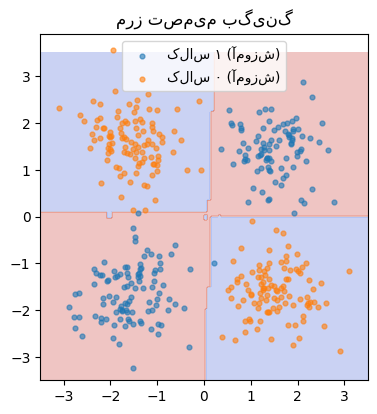

In [11]:
class BaggedTrees:
    def __init__(self, n_estimators=25, max_depth=5):
        self.n_estimators = n_estimators
        self.max_depth = max_depth

    def fit(self, X, y):
        rng = np.random.default_rng(SEED + 7)
        self.trees_ = []
        for _ in range(self.n_estimators):
            boot = rng.integers(0, len(X), size=len(X))   # bootstrap with replacement
            tree = DecisionTree(max_depth=self.max_depth).fit(X[boot], y[boot])
            self.trees_.append(tree)
        return self

    def predict(self, X):
        preds = np.array([t.predict(X) for t in self.trees_])   # (B, n)
        maj = []
        for j in range(X.shape[0]):
            vals, counts = np.unique(preds[:, j], return_counts=True)
            maj.append(vals[np.argmax(counts)])
        return np.array(maj)

bag = BaggedTrees(n_estimators=25, max_depth=5).fit(X2_tr, y2_tr)
print(f"bagging — دقت آموزش: {(bag.predict(X2_tr)==y2_tr).mean():.4f} | دقت آزمون: {(bag.predict(X2_te)==y2_te).mean():.4f}")

# مرز تصمیم
xx, yy = np.meshgrid(np.linspace(-3.5, 3.5, 200), np.linspace(-3.5, 3.5, 200))
zz = bag.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.contourf(xx, yy, zz, alpha=0.3, cmap='coolwarm')
plot_t2('مرز تصمیم bagging'); plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

**۲-د) (۴ نمره)** در یک سلول markdown توضیح دهید: چرا تک‌درختِ عمیق روی این داده واریانس بالایی دارد و bagging چگونه این واریانس را کم می‌کند؟ حدس بزنید (و با یک آزمایش کوتاه عددی بررسی کنید) اگر به‌جای نمونه‌برداری bootstrap از کل داده برای همهٔ درخت‌ها استفاده کنیم چه اتفاقی می‌افتد؟

</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

**پاسخ:** تک‌درخت عمیق مرزهای بسیار پیچیده و تیز می‌سازد که به نمونه‌های تصادفی آموزش حساس است (واریانس بالا). bagging با آموزش روی نمونه‌های bootstrap متفاوت و میانگین‌گیری رأی، خطاهای واریانسی هم‌جهت را حذف می‌کند و مرز هموارتری می‌دهد. اگر همهٔ درخت‌ها روی کل داده (بدون bootstrap) آموزش ببینند و شکاف‌ها قطعی (greedy) باشد، همهٔ درخت‌ها عملاً یکسان می‌شوند و bagging فایده‌ای ندارد — این را با آزمایش هم می‌بینیم (دقت همان تک‌درخت می‌ماند).

</div>

In [12]:
# آزمایش: bagging بدون bootstrap (همهٔ درخت‌ها روی کل داده)
class IdenticalTrees:
    def fit(self, X, y):
        self.trees_ = [DecisionTree(max_depth=5).fit(X, y) for _ in range(25)]
        return self
    def predict(self, X):
        preds = np.array([t.predict(X) for t in self.trees_])
        return preds[0]  # همه یکسان‌اند

ident = IdenticalTrees().fit(X2_tr, y2_tr)
print("بدون bootstrap، همهٔ درخت‌ها یکسان‌اند؛ دقت آزمون:",
      (ident.predict(X2_te)==y2_te).mean())

بدون bootstrap، همهٔ درخت‌ها یکسان‌اند؛ دقت آزمون: 0.995


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

## مسئلهٔ ۳ — PCA و خوشه‌بندی k-means از صفر (۲۵ نمره)

در این مسئله دادهٔ گل‌مانند سه‌بعدی (خوشه‌های کشیده در جهات همبسته) می‌سازیم؛ ابتدا PCA را با تجزیه ویژه پیاده می‌کنیم و سپس k-means را با مقداردهی k-means++.

</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

</div>

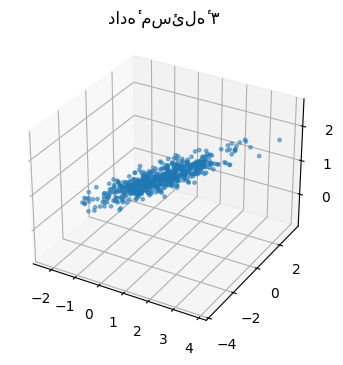

In [13]:
# ساخت داده — فقط اجرا کنید، تغییر ندهید
rng = np.random.default_rng(SEED + 2)
n = 600
# دادهٔ سه‌بعدی با ساختار رتبهٔ ~۲ (روی یک صفحهٔ کج در R^3)
z = rng.normal(size=(n, 2))
basis = np.array([[1.0, 0.2, 0.5],
                  [0.1, 1.0, -0.3]])          # دو جهت اصلی
X_t3 = z @ basis + np.array([0.5, -0.5, 1.0]) # جابه‌جایی
X_t3 += rng.normal(scale=0.05, size=X_t3.shape)  # نویز کوچک

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(121, projection='3d'); ax.scatter(*X_t3.T, s=6, alpha=0.5); ax.set_title('دادهٔ مسئلهٔ ۳')
plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

**۳-الف) (۸ نمره)** تابع `pca(X, k)` را بنویسید: میانگین را کم کنید، ماتریس کوواریانس تجربی ⁦$\Sigma = \frac{1}{n-1}(X-\mu)^\top(X-\mu)$⁩ را بسازید، با `np.linalg.eigh` بردارهای ویژه را بگیرید و ⁦$k$⁩ principal components (مرتب‌شده نزولی) و explained variance ratio را برگردانید. سپس:
1. explained variance ratioٔ مؤلفه‌های ۱ تا ۳ را چاپ کنید؛
2. داده را با ⁦$k=2$⁩ روی دو مؤلفهٔ اول تصویر و پراکنش‌شان را رسم کنید؛
3. **خطای بازسازی نسبی** ⁦$\frac{\|X - \hat{X}\|_F^2}{\|X\|_F^2}$⁩ را برای ⁦$k=1,2,3$⁩ حساب و چاپ کنید (برای بازسازی، ⁦$\mu$⁩ را برگردانید) و رابطه‌اش را با نسبت واریانس باقی‌مانده مقایسه کنید.

</div>

نسبت واریانس تبیین‌شده (k=1..3): [0.5923 0.4067 0.001 ]


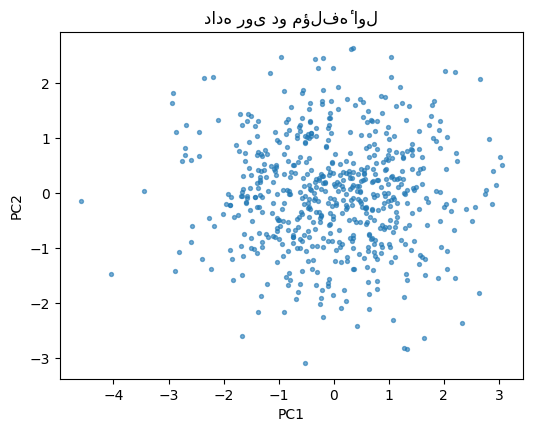

k=1: خطای بازسازی نسبی = 0.407671 | واریانس باقی‌مانده = 0.407671
k=2: خطای بازسازی نسبی = 0.000976 | واریانس باقی‌مانده = 0.000976
k=3: خطای بازسازی نسبی = 0.000000 | واریانس باقی‌مانده = 0.000000


In [14]:
def pca(X, k):
    mu = X.mean(axis=0)
    Xc = X - mu
    Sigma = (Xc.T @ Xc) / (len(X) - 1)
    evals, evecs = np.linalg.eigh(Sigma)
    order = np.argsort(evals)[::-1]        # نزولی
    evals, evecs = evals[order], evecs[:, order]
    components = evecs[:, :k].T            # (k, d)
    explained_ratio = evals[:k] / evals.sum()
    return components, explained_ratio, mu

def reconstruct(X, k):
    components, _, mu = pca(X, k)
    Xc = X - mu
    Z = Xc @ components.T                  # (n, k) نمره‌ها
    return Z @ components + mu             # بازسازی

comps, ratio, mu = pca(X_t3, 3)
print("نسبت واریانس تبیین‌شده (k=1..3):", ratio.round(4))

Z2 = (X_t3 - mu) @ comps[:2].T
plt.scatter(Z2[:,0], Z2[:,1], s=8, alpha=0.6)
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('داده روی دو مؤلفهٔ اول'); plt.gca().set_aspect('equal'); plt.show()

Xn = X_t3 - X_t3.mean(0)   # برای مقایسهٔ صحیح، نُرم دادهٔ مرکزشده
for k in [1, 2, 3]:
    Xhat = reconstruct(X_t3, k)
    rel = ((X_t3 - Xhat)**2).sum() / (Xn**2).sum()
    remaining = 1 - ratio[:k].sum()
    print(f"k={k}: خطای بازسازی نسبی = {rel:.6f} | واریانس باقی‌مانده = {remaining:.6f}")

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

**۳-ب) (۸ نمره)** k-means از صفر: توابع `kmeans_pp_init(X, k, rng)` و `kmeans(X, k, max_iter=100)` را بنویسید. الگوریتم تا همگرایی (عدم تغییر انتساب‌ها) یا `max_iter` تکرار می‌شود و `(labels, centers, inertia)` را برمی‌گرداند که `inertia` مجموع مربع فاصلهٔ نقاط تا مرکز خوشه‌شان است. روی دادهٔ مسئلهٔ ۱ (`X_t1`، دو خوشهٔ هم‌پوشان) با ⁦$k=2$⁩ اجرا کنید، خوشه‌ها را رسم کنید و inertia را گزارش کنید.

**توجه:** الگوریتم k-means++ برای مقداردهی اولیه: مرکز اول تصادفی؛ هر مرکز بعدی از میان نقاط داده با احتمال متناسب با مجذور فاصلهٔ تا نزدیک‌ترین مرکز موجود انتخاب می‌شود.

</div>

inertia = 1282.55


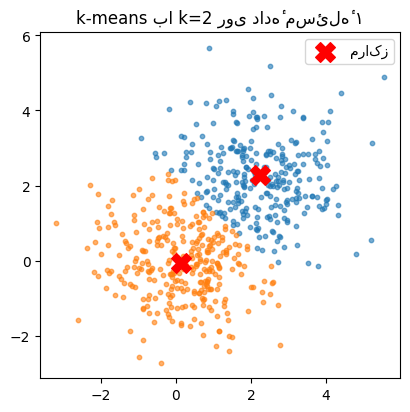

In [15]:
def kmeans_pp_init(X, k, rng):
    n = len(X)
    centers = [X[rng.integers(n)]]
    for _ in range(1, k):
        d2 = np.min(((X[:, None, :] - np.array(centers)[None, :, :])**2).sum(-1), axis=1)
        probs = d2 / d2.sum()
        centers.append(X[rng.choice(n, p=probs)])
    return np.array(centers)

def kmeans(X, k, max_iter=100):
    rng = np.random.default_rng(SEED + 3)
    centers = kmeans_pp_init(X, k, rng)
    for _ in range(max_iter):
        d2 = ((X[:, None, :] - centers[None, :, :])**2).sum(-1)   # (n, k)
        labels = d2.argmin(axis=1)
        new_centers = centers.copy()
        for j in range(k):
            if (labels == j).any():
                new_centers[j] = X[labels == j].mean(axis=0)
        if np.allclose(new_centers, centers):
            break
        centers = new_centers
    d2 = ((X[:, None, :] - centers[None, :, :])**2).sum(-1)
    labels = d2.argmin(axis=1)
    inertia = d2[np.arange(len(X)), labels].sum()
    return labels, centers, inertia

labels_t3, centers_t3, inertia_t3 = kmeans(X_t1, 2)
print(f"inertia = {inertia_t3:.2f}")
for j, c in [(0, 'tab:blue'), (1, 'tab:orange')]:
    plt.scatter(X_t1[labels_t3==j][:,0], X_t1[labels_t3==j][:,1], s=10, alpha=0.6, c=c)
plt.scatter(centers_t3[:,0], centers_t3[:,1], marker='X', s=200, c='red', label='مراکز')
plt.legend(); plt.gca().set_aspect('equal'); plt.title('k-means با k=2 روی دادهٔ مسئلهٔ ۱'); plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

**۳-ج) (۵ نمره)** با اجرای k-means با ۱۰ مقداردهی اولیهٔ متفاوت (seedهای مختلف)، نمودار مقادیر inertia را رسم کنید. آیا همیشه به سراسری‌ترین کمینه می‌رسد؟ سپس با روش «آرنج» (elbow) برای ⁦$k = 1,\dots,6$⁩ روی دادهٔ مسئلهٔ ۱، inertia بر حسب ⁦$k$⁩ را رسم کنید و بگویید چه ⁦$k$⁩ای طبیعی به نظر می‌رسد.

</div>

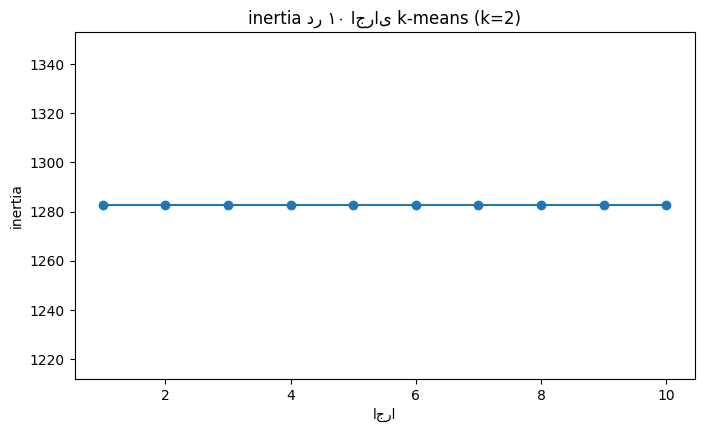

inertiaها: [1282.55 1282.55 1282.55 1282.55 1282.55 1282.55 1282.55 1282.55 1282.55
 1282.55]


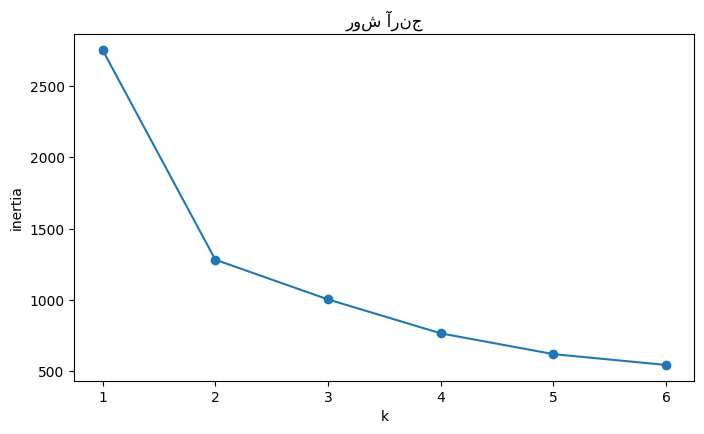

In [16]:
inertias = []
for s in range(10):
    rng = np.random.default_rng(SEED + 100 + s)
    def km(X, k):
        centers = kmeans_pp_init(X, k, rng)
        for _ in range(100):
            d2 = ((X[:, None, :] - centers[None, :, :])**2).sum(-1)
            labels = d2.argmin(1)
            newc = centers.copy()
            for j in range(k):
                if (labels==j).any(): newc[j] = X[labels==j].mean(0)
            if np.allclose(newc, centers): break
            centers = newc
        d2 = ((X[:, None, :] - centers[None, :, :])**2).sum(-1)
        labels = d2.argmin(1)
        return labels, centers, d2[np.arange(len(X)), labels].sum()
    _, _, inert = km(X_t1, 2)
    inertias.append(inert)
plt.plot(range(1, 11), inertias, 'o-'); plt.xlabel('اجرا'); plt.ylabel('inertia')
plt.title('inertia در ۱۰ اجرای k-means (k=2)'); plt.show()
print("inertiaها:", np.round(inertias, 2))

ks = range(1, 7)
inert = []
for k in ks:
    _, _, i_k = kmeans(X_t1, k)
    inert.append(i_k)
plt.plot(list(ks), inert, 'o-'); plt.xlabel('k'); plt.ylabel('inertia')
plt.title('روش آرنج'); plt.xticks(list(ks)); plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

**۳-د) (۴ نمره)** پیوند PCA و k-means: دادهٔ مسئلهٔ ۳ را با PCA به ⁦$k=2$⁩ بُعد ببرید، k-means را روی دادهٔ کاهش‌بُعد‌یافته اجرا کنید و نتیجه را با اجرای k-means روی دادهٔ اصلی سه‌بعدی مقایسه کنید (inertia را در فضای اصلی برای هر دو محاسبه کنید). آیا کاهش بُعد به هزینهٔ خوشه‌بندی افت کرد؟ چرا؟

</div>

In [17]:
# اجرای k-means روی دادهٔ کاهش‌بُعد یافته (PCA → 2D) و مقایسه
Z2_full = (X_t3 - mu) @ comps[:2].T          # (n, 2)
labels_pca, centers_pca, _ = kmeans(Z2_full, 2)
# مراکز را به فضای اصلی برگردانیم
centers_orig = centers_pca @ comps[:2] + mu
inertia_pca = ((X_t3 - centers_orig[labels_pca])**2).sum()

labels_full, centers_full, inertia_full = kmeans(X_t3, 2)
print(f"inertia پس از کاهش بعد (در فضای اصلی): {inertia_pca:.3f}")
print(f"inertia k-means مستقیم روی فضای اصلی:   {inertia_full:.3f}")
agree = (labels_pca == labels_full).mean()
print(f"توافق برچسب‌ها (به‌صورت مستقیم): {max(agree, 1-agree):.3f}")

inertia پس از کاهش بعد (در فضای اصلی): 900.272
inertia k-means مستقیم روی فضای اصلی:   900.272
توافق برچسب‌ها (به‌صورت مستقیم): 1.000


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

**پاسخ:** دادهٔ مسئلهٔ ۳ اساساً روی یک صفحهٔ دو‌بعدی (رتبهٔ ≈۲) قرار دارد؛ PCA مؤلفهٔ سوم (نویز کوچک 0.05) را حذف می‌کند که تقریباً هیچ اطلاعات خوشه‌ای ندارد؛ بنابراین خوشه‌بندی در فضای کاهش‌یافته عملاً همان نتیجه را می‌دهد و inertia در فضای اصلی تقریباً برابر می‌ماند. کاهش بُعد وقتی به خوشه‌بندی آسیب می‌زند که مؤلفه‌های حذف‌شده حاوی اطلاعات تفکیک‌کنندهٔ خوشه‌ها باشند.

</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

## مسئلهٔ ۴ — MLP و بهینه‌ساز Adam از صفر (۲۵ نمره)

شبکهٔ عصبی دولایه را **کاملاً از صفر با NumPy** می‌سازیم: backpropagation دستی و بهینه‌ساز Adam. دادهٔ مسئله، دو مارپیچ (spirals) است که با هیچ مدل خطی جدا نمی‌شود.

</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

</div>

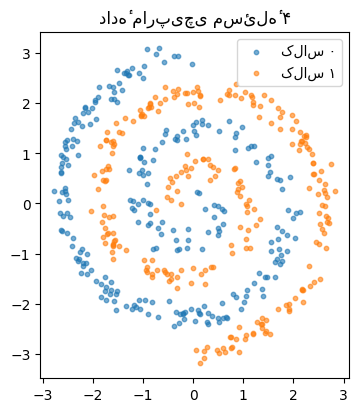

In [18]:
# ساخت داده — فقط اجرا کنید، تغییر ندهید
rng = np.random.default_rng(SEED + 4)
n_per = 250
def make_spiral(n, delta, rng):
    r = np.sqrt(rng.random(n)) * 3.0
    t = 4.0 * np.pi * r / 3.0 + delta
    X = np.c_[r * np.sin(t), r * np.cos(t)] + rng.normal(0, 0.12, (n, 2))
    return X
X_t4 = np.vstack([make_spiral(n_per, 0, rng), make_spiral(n_per, np.pi, rng)])
y_t4 = np.hstack([np.zeros(n_per), np.ones(n_per)]).astype(int)
idx = rng.permutation(len(X_t4)); n_tr = 400
tr4, te4 = idx[:n_tr], idx[n_tr:]
X4_tr, y4_tr, X4_te, y4_te = X_t4[tr4], y_t4[tr4], X_t4[te4], y_t4[te4]

plt.scatter(X_t4[y_t4==0][:,0], X_t4[y_t4==0][:,1], s=10, alpha=0.6, label='کلاس ۰')
plt.scatter(X_t4[y_t4==1][:,0], X_t4[y_t4==1][:,1], s=10, alpha=0.6, label='کلاس ۱')
plt.legend(); plt.gca().set_aspect('equal'); plt.title('دادهٔ مارپیچی مسئلهٔ ۴'); plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

**۴-الف) (۱۰ نمره)** کلاس `MLP` را با معماری ⁦$2 \to 64 \to 64 \to 2$⁩ (خروجی logits برای دو کلاس) و فعال‌سازی ReLU بنویسید. متدها:
- `forward(X)`: خروجی logits شکل ⁦$(n, 2)$⁩؛ مقادیر میانی را برای backpropagation ذخیره کند؛
- `backward(X, y_onehot)`: backpropagation از هزینهٔ softmax + cross-entropy (گرادیان مشترک ⁦$\hat{p} - y$⁩)؛ گرادیان‌ها را در دیکشنری `grads` بریزد؛
- `params`: دیکشنری پارامترها.

**راهنمایی گرادیان خروجی:** اگر ⁦$L$⁩ cross-entropy با softmax باشد، ⁦$\frac{\partial L}{\partial a^{(L)}} = \frac{1}{n}(\mathrm{softmax}(a^{(L)}) - Y_{onehot})$⁩.

</div>

In [19]:
class MLP:
    def __init__(self, hidden=(64, 64), seed=SEED):
        rng = np.random.default_rng(seed)
        dims = [2, *hidden, 2]
        self.W = [rng.normal(0, np.sqrt(2.0/dims[i]), (dims[i], dims[i+1])) for i in range(len(dims)-1)]
        self.b = [np.zeros(dims[i+1]) for i in range(len(dims)-1)]
        self.grads = {}

    @property
    def params(self):
        return {'W': self.W, 'b': self.b}

    def forward(self, X):
        self.cache = []
        a = X
        L = len(self.W)
        for i in range(L):
            z = a @ self.W[i] + self.b[i]
            if i < L - 1:
                a_next = np.maximum(0, z)          # ReLU
            else:
                a_next = z                          # logits
            self.cache.append((a, z))
            a = a_next
        return a

    def softmax(self, Z):
        Z = Z - Z.max(axis=1, keepdims=True)
        e = np.exp(Z)
        return e / e.sum(axis=1, keepdims=True)

    def backward(self, X, Y_onehot):
        n = len(X)
        logits = self.forward(X)
        P = self.softmax(logits)
        delta = (P - Y_onehot) / n                  # (n, 2) گرادیان لایهٔ خروجی
        L = len(self.W)
        for i in range(L - 1, -1, -1):
            a_prev, _ = self.cache[i]
            self.grads[f'dW{i}'] = a_prev.T @ delta
            self.grads[f'db{i}'] = delta.sum(axis=0)
            if i > 0:
                a_prev2, z_prev = self.cache[i-1]
                delta = (delta @ self.W[i].T) * (z_prev > 0)   # پس‌انتشار از ReLU
        return self.grads

def to_onehot(y, C=2):
    Y = np.zeros((len(y), C)); Y[np.arange(len(y)), y] = 1
    return Y

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

</div>

In [20]:
# بررسی گرادیان با تفاضل متناهی — فقط اجرا کنید
mlp = MLP(hidden=(8, 8), seed=SEED)
Xs_ = X4_tr[:20]; Ys_ = to_onehot(y4_tr[:20])
mlp.forward(Xs_); mlp.backward(Xs_, Ys_)
logits = mlp.forward(Xs_)

def loss_of(mlp, X, Y):
    P = mlp.softmax(mlp.forward(X))
    return -np.mean(np.log((P * Y).sum(1) + 1e-300))

eps = 1e-6
# بررسی dW0[0,0] و db1[1]
i, j = 0, 0
old = mlp.W[0][i, j]
mlp.W[0][i, j] = old + eps; lp = loss_of(mlp, Xs_, Ys_)
mlp.W[0][i, j] = old - eps; lm = loss_of(mlp, Xs_, Ys_)
mlp.W[0][i, j] = old
num = (lp - lm) / (2 * eps)
assert abs(num - mlp.grads['dW0'][i, j]) < 1e-5, f"dW0 mismatch: {num} vs {mlp.grads['dW0'][i,j]}"
old = mlp.b[1][1]
mlp.b[1][1] = old + eps; lp = loss_of(mlp, Xs_, Ys_)
mlp.b[1][1] = old - eps; lm = loss_of(mlp, Xs_, Ys_)
mlp.b[1][1] = old
num = (lp - lm) / (2 * eps)
assert abs(num - mlp.grads['db1'][1]) < 1e-5, f"db1 mismatch: {num} vs {mlp.grads['db1'][1]}"
print("گرادیان‌های MLP با تفاضل متناهی سازگارند ✓")

گرادیان‌های MLP با تفاضل متناهی سازگارند ✓


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

**۴-ب) (۸ نمره)** بهینه‌ساز Adam را پیاده کنید: کلاس `Adam` با به‌روزرسانی

<div dir="ltr">

$$
m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t, \quad v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2
$$

</div>
<div dir="ltr">

$$
\hat m = \frac{m_t}{1-\beta_1^t}, \quad \hat v = \frac{v_t}{1-\beta_2^t}, \quad \theta \leftarrow \theta - \eta \frac{\hat m}{\sqrt{\hat v} + \epsilon}
$$

</div>

با پیش‌فرض‌های ⁦$\beta_1=0.9$⁩، ⁦$\beta_2=0.999$⁩، ⁦$\epsilon=10^{-8}$⁩. سپس حلقهٔ آموزش `train_mlp(optimizer='sgd' یا 'adam', lr, epochs)` بنویسید که **full-batch** آموزش می‌دهد و تاریخچهٔ هزینه را برمی‌گرداند. هر دو بهینه‌ساز را با نرخ یادگیری یکسان ⁦$0.01$⁩ آموزش دهید، منحنی هزینه‌ها را در یک نمودار مقایسه کنید و دقت آزمون هر دو را گزارش کنید.

</div>

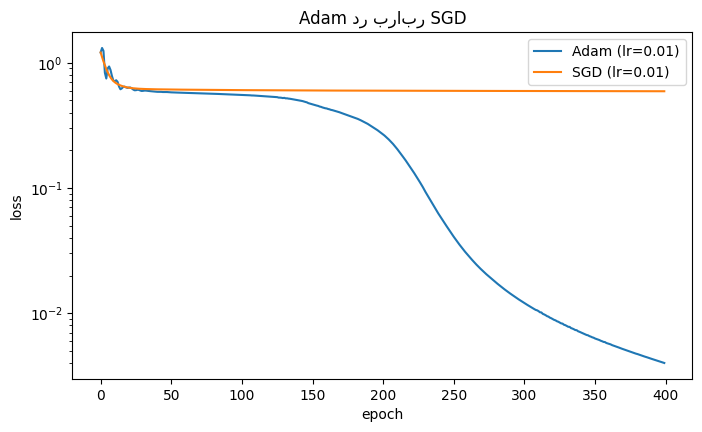

Adam: دقت آموزش 1.000 | دقت آزمون 0.990
SGD:  دقت آموزش 0.662 | دقت آزمون 0.600


In [21]:
class Adam:
    def __init__(self, params, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params = params
        self.lr, self.beta1, self.beta2, self.eps = lr, beta1, beta2, eps
        self.t = 0
        self.m = {k: [np.zeros_like(p) for p in v] for k, v in params.items()}
        self.v = {k: [np.zeros_like(p) for p in v] for k, v in params.items()}

    def step(self, grads):
        self.t += 1
        for key in self.params:
            plist = self.params[key]
            for i in range(len(plist)):
                g = grads[f'd{key}{i}']
                self.m[key][i] = self.beta1 * self.m[key][i] + (1 - self.beta1) * g
                self.v[key][i] = self.beta2 * self.v[key][i] + (1 - self.beta2) * g**2
                m_hat = self.m[key][i] / (1 - self.beta1 ** self.t)
                v_hat = self.v[key][i] / (1 - self.beta2 ** self.t)
                plist[i] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

def train_mlp(X, y, optimizer='adam', lr=0.01, epochs=300, seed=SEED):
    mlp = MLP(seed=seed)
    Y = to_onehot(y)
    if optimizer == 'adam':
        opt = Adam(mlp.params, lr=lr)
    history = []
    for ep in range(epochs):
        logits = mlp.forward(X)
        P = mlp.softmax(logits)
        loss = -np.mean(np.log((P * Y).sum(1) + 1e-300))
        history.append(loss)
        mlp.backward(X, Y)
        if optimizer == 'adam':
            opt.step(mlp.grads)
        else:  # sgd
            for i in range(len(mlp.W)):
                mlp.W[i] -= lr * mlp.grads[f'dW{i}']
                mlp.b[i] -= lr * mlp.grads[f'db{i}']
    return mlp, history

mlp_adam, hist_adam = train_mlp(X4_tr, y4_tr, 'adam', lr=0.01, epochs=400)
mlp_sgd, hist_sgd = train_mlp(X4_tr, y4_tr, 'sgd', lr=0.01, epochs=400)
plt.plot(hist_adam, label='Adam (lr=0.01)')
plt.plot(hist_sgd, label='SGD (lr=0.01)')
plt.yscale('log'); plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.title('Adam در برابر SGD'); plt.show()

def mlp_acc(mlp, X, y):
    return (mlp.forward(X).argmax(1) == y).mean()
print(f"Adam: دقت آموزش {mlp_acc(mlp_adam, X4_tr, y4_tr):.3f} | دقت آزمون {mlp_acc(mlp_adam, X4_te, y4_te):.3f}")
print(f"SGD:  دقت آموزش {mlp_acc(mlp_sgd, X4_tr, y4_tr):.3f} | دقت آزمون {mlp_acc(mlp_sgd, X4_te, y4_te):.3f}")

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

**۴-ج) (۷ نمره)** مرز تصمیم: مرز تصمیم مدل Adam را روی شبکهٔ نقاط ⁦$[-3.5, 3.5]^2$⁩ با colormap رسم کنید (احتمال کلاس ۱). سپس در یک سلول markdown توضیح دهید: (۱) چرا مدل خطی (مثل مسئلهٔ ۱) روی این داده شکست می‌خورد؛ (۲) تفاوت رفتار همگرایی Adam و SGD که در نمودار دیدید و نقش گام‌های تطبیقی.

</div>

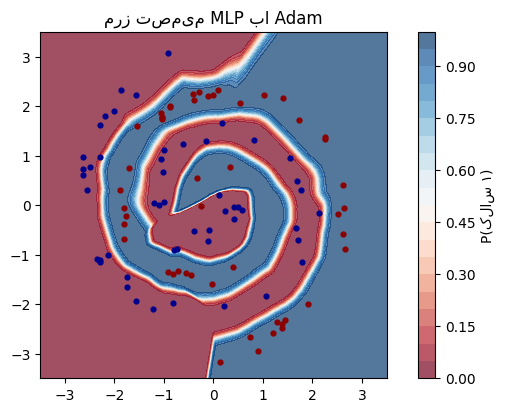

In [22]:
xx, yy = np.meshgrid(np.linspace(-3.5, 3.5, 250), np.linspace(-3.5, 3.5, 250))
grid = np.c_[xx.ravel(), yy.ravel()]
probs = mlp_adam.softmax(mlp_adam.forward(grid))[:, 1].reshape(xx.shape)
plt.contourf(xx, yy, probs, levels=20, cmap='RdBu', alpha=0.7)
plt.colorbar(label='P(کلاس ۱)')
plt.scatter(X4_te[y4_te==0][:,0], X4_te[y4_te==0][:,1], s=12, c='darkblue')
plt.scatter(X4_te[y4_te==1][:,0], X4_te[y4_te==1][:,1], s=12, c='darkred')
plt.gca().set_aspect('equal'); plt.title('مرز تصمیم MLP با Adam'); plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

**پاسخ:** (۱) دادهٔ مارپیچ با هیچ خط جدا نمی‌شود — پیچش کلاس‌ها یعنی مرز تصمیم باید غیرخطی و پیچیده باشد؛ رگرسیون لجستیک فقط یک خط می‌دهد و دقتش نزدیک ۵۰٪ می‌مانَد. (۲) Adam با نرخ یادگیری یکسان، سریع‌تر و یکنواتر همگرا می‌شود چون گام مؤثر هر پارامتر را با تبدیل ⁦$\hat m/\sqrt{\hat v}$⁩ نرمال می‌کند (پارامترهایی با گرادیان کمنوسان، گام بزرگ‌تر و بالعکس)؛ SGD با lr ثابت 0.01 روی شبکهٔ بدون نرمال‌سازیِ ورودی کند است چون مقیاس گرادیان‌ها در لایه‌های مختلف متفاوت است و برای لایه‌های اول گرادیان کوچک‌تر می‌شود.

</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

## مسئلهٔ ۵ — شبکهٔ کانولوشنی با PyTorch (۲۵ نمره)

یک مجموعه‌دادهٔ تصویری **سنتزی** می‌سازیم: تصاویر سیاه‌وسفید ⁦$28\times28$⁩ که در آن‌ها یا «دایره» یا «مربع» یا «مثلث» (کلاس‌ها) در مکان و اندازهٔ تصادفی رسم شده است. سپس یک CNN کوچک برای طبقه‌بندی شکل آموزش می‌دهیم — همه‌چیز روی CPU و در چند دقیقه.

</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

</div>

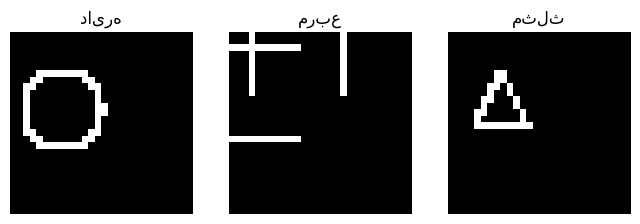

ابعاد دادهٔ آموزش: (1200, 1, 28, 28) | آزمون: (300, 1, 28, 28)


In [23]:
# ساخت داده — فقط اجرا کنید، تغییر ندهید
import math
def draw_shape(img, cls, rng):
    cx, cy = rng.integers(8, 20), rng.integers(8, 20)
    r = rng.integers(4, 8)
    if cls == 0:      # دایره
        for t in np.linspace(0, 2*np.pi, 200):
            x, y = int(cx + r*np.cos(t)), int(cy + r*np.sin(t))
            if 0 <= x < 28 and 0 <= y < 28: img[y, x] = 1
    elif cls == 1:    # مربع
        x0, y0 = cx - r, cy - r
        for s in np.linspace(-r, r, 4*r+1):
            for (x, y) in [(x0+s, y0), (x0+s, y0+2*r), (x0, y0+s), (x0+2*r, y0+s)]:
                if 0 <= x < 28 and 0 <= y < 28: img[int(y), int(x)] = 1
    else:             # مثلث
        pts = [(cx, cy - r), (cx - r, cy + r), (cx + r, cy + r)]
        for (x1, y1), (x2, y2) in [(pts[0], pts[1]), (pts[1], pts[2]), (pts[2], pts[0])]:
            for s in np.linspace(0, 1, 4*r+1):
                x, y = int(x1 + s*(x2-x1)), int(y1 + s*(y2-y1))
                if 0 <= x < 28 and 0 <= y < 28: img[y, x] = 1

def make_shapes_dataset(n_per, seed):
    rng = np.random.default_rng(seed)
    X = np.zeros((3*n_per, 1, 28, 28), dtype=np.float32)
    y = np.zeros(3*n_per, dtype=np.int64)
    for i in range(3*n_per):
        cls = i % 3
        draw_shape(X[i, 0], cls, rng)
        y[i] = cls
    return X, y

Xc_tr, yc_tr = make_shapes_dataset(400, SEED)
Xc_te, yc_te = make_shapes_dataset(100, SEED + 50)
fig, axes = plt.subplots(1, 3, figsize=(8, 3))
for c, name in enumerate(['دایره', 'مربع', 'مثلث']):
    axes[c].imshow(Xc_tr[yc_tr == c][0, 0], cmap='gray'); axes[c].set_title(name); axes[c].axis('off')
plt.show()
print("ابعاد دادهٔ آموزش:", Xc_tr.shape, "| آزمون:", Xc_te.shape)

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

**۵-الف) (۵ نمره)** پاسخ دهید (در سلول markdown، با محاسبهٔ دستی):
1. یک لایهٔ `nn.Conv2d(1, 16, kernel_size=3, padding=1)` چند پارامتر (وزن + بایاس) دارد؟
2. اگر ورودی ⁦$1\times28\times28$⁩ از سه لایهٔ کانولوشنی (کرنل ⁦$3\times3$⁩، padding=1، stride=1) با ۱۶، ۳۲ و ۳۲ کانال و سپس `AdaptiveAvgPool2d(1)` عبور کند، ابعاد تانسور در هر مرحله چیست؟
3. چرا برای این مسئله CNN نسبت به MLP با ورودی مسطح (⁦$784$⁩) مناسب‌تر است؟ (دو دلیل بنویسید.)

</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

**پاسخ:**
1. وزن‌ها: ⁦$16\times1\times3\times3 = 144$⁩ و بایاس: ⁦$16$⁩؛ در کل ⁦$160$⁩ پارامتر.
2. ⁦$1{\times}28{\times}28 \to 16{\times}28{\times}28 \to 32{\times}28{\times}28 \to 32{\times}28{\times}28 \to 32{\times}1{\times}1$⁩ (و پس از flatten: ⁦$32$⁩).
3. (الف) translation equivariance: فیلتر کانولوشن همان الگو (لبه، کمان) را در هر جای تصویر تشخیص می‌دهد — اشکال در مکان‌های تصادفی رسم شده‌اند و MLP مسطح باید همین وزن‌ها را برای هر مکان جدا یاد بگیرد (پارامتر خیلی بیشتر، داده بیشتر لازم). (ب) ساختار محلی: پیکسل‌های مجاور وابسته‌اند؛ کانولوشن همین درون‌ساخت را در معماری می‌گنجاند و نمونه‌های جدید از جابه‌جایی و تغییر اندازهٔ شکل بهتر تعمیم می‌یابد.

</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

**۵-ب) (۱۰ نمره)** کلاس `ShapeCNN` را بنویسید با معماری: سه بلوک [`Conv2d(3×3, pad=1)` + `BatchNorm2d` + `ReLU` + `MaxPool2d(2)`] با کانال‌های ۱۶، ۳۲، ۶۴، سپس `AdaptiveAvgPool2d(1)` و یک لایهٔ خطی به ۳ کلاس. تابع `count_params(model)` را هم بنویسید که تعداد کل پارامترهای آموزش‌پذیر را برگرداند و برای مدل خودتان چاپ کنید.

</div>

In [24]:
class ShapeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1),
                nn.BatchNorm2d(cout),
                nn.ReLU(),
                nn.MaxPool2d(2),
            )
        self.features = nn.Sequential(block(1, 16), block(16, 32), block(32, 64))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Linear(64, 3)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)
        return self.head(x)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model_cnn = ShapeCNN()
print("پارامترهای قابل آموزش:", count_params(model_cnn))

پارامترهای قابل آموزش: 23715


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

**۵-ج) (۱۰ نمره)** حلقهٔ آموزش بنویسید: `CrossEntropyLoss`، بهینه‌ساز `Adam` با lr=⁦$10^{-3}$⁩، ۳ epoch، اندازهٔ batch=64. در هر epoch دقت آموزش و در پایان دقت آزمون را گزارش کنید (توقع: دقت آزمون بالای ⁦$95\%$⁩). سپس **confusion matrix** ⁦$3\times3$⁩ را برای دادهٔ آزمون به‌صورت عددی چاپ یا رسم کنید و بگویید مدل در تشخیص کدام دو شکل بیشترین اشتباه را داشته است.

</div>

epoch 1: loss=0.5395 | دقت آموزش: 0.8958
epoch 2: loss=0.1056 | دقت آموزش: 1.0000


epoch 3: loss=0.0306 | دقت آموزش: 1.0000
دقت آزمون: 1.0000
confusion matrix (سطر=واقعی، ستون=پیش‌بینی):
[[100   0   0]
 [  0 100   0]
 [  0   0 100]]


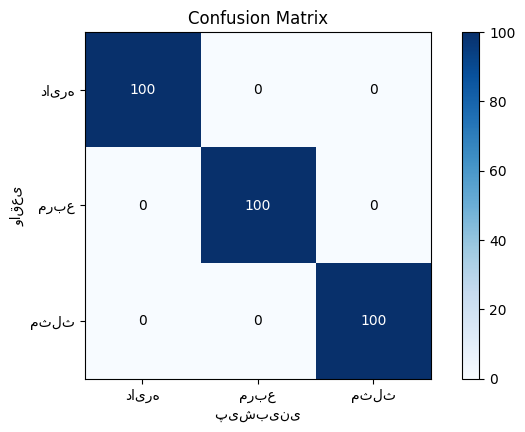

1.0

In [25]:
def train_cnn(model, X, y, X_te, y_te, epochs=3, bs=64, lr=1e-3):
    Xt = torch.tensor(X); yt = torch.tensor(y)
    Xte = torch.tensor(X_te); yte = torch.tensor(y_te)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.CrossEntropyLoss()
    model.train()
    for ep in range(epochs):
        perm = torch.randperm(len(Xt))
        tot, correct, losses = 0, 0, []
        for i in range(0, len(Xt), bs):
            b = perm[i:i+bs]
            opt.zero_grad()
            out = model(Xt[b])
            loss = lossf(out, yt[b])
            loss.backward(); opt.step()
            losses.append(loss.item())
            correct += (out.argmax(1) == yt[b]).sum().item(); tot += len(b)
        print(f"epoch {ep+1}: loss={np.mean(losses):.4f} | دقت آموزش: {correct/tot:.4f}")
    model.eval()
    with torch.no_grad():
        pred = model(Xte).argmax(1)
    acc = (pred == yte).float().mean().item()
    print(f"دقت آزمون: {acc:.4f}")
    # confusion matrix
    C = np.zeros((3, 3), dtype=int)
    for t, p in zip(yte.numpy(), pred.numpy()):
        C[t, p] += 1
    print("confusion matrix (سطر=واقعی، ستون=پیش‌بینی):")
    print(C)
    plt.imshow(C, cmap='Blues'); plt.colorbar()
    plt.xticks(range(3), ['دایره','مربع','مثلث']); plt.yticks(range(3), ['دایره','مربع','مثلث'])
    for a in range(3):
        for b_ in range(3):
            plt.text(b_, a, C[a, b_], ha='center', va='center',
                     color='white' if C[a,b_] > C.max()/2 else 'black')
    plt.title('Confusion Matrix'); plt.xlabel('پیش‌بینی'); plt.ylabel('واقعی'); plt.show()
    return acc

train_cnn(model_cnn, Xc_tr, yc_tr, Xc_te, yc_te)

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

## مسئلهٔ ۶ — attention و Transformer کوچک (۲۵ نمره)

در این مسئله اول هستهٔ اصلی Transformer — یعنی scaled dot-product attention — را از صفر پیاده می‌کنیم و بعد یک Transformer کوچک روی یک وظیفهٔ الگوریتمی آموزش می‌دهیم.

**وظیفه:** دنباله‌هایی از ارقام ⁦$0..9$⁩ به طول ⁦$12$⁩ داده می‌شود؛ مدل باید تعداد ارقامی که **بزرگ‌تر یا مساوی ۵** هستند را بشمارد و به‌صورت یکی از ۱۳ کلاس (⁦$0..12$⁩) خروجی دهد. یعنی برچسب = ⁦$\big|\{i : x_i \ge 5\}\big|$⁩. این وظیفه یک selective counting است: مدل باید یاد بگیرد با توجه، فقط توکن‌های «بزرگ» را جمع بزند و از بقیه صرف‌نظر کند.

</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

**۶-الف) (۸ نمره)** تابع `scaled_dot_product_attention(Q, K, V)` را بنویسید:

<div dir="ltr">

$$
\mathrm{Attn}(Q,K,V) = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V
$$

</div>

ورودی‌ها شکل ⁦$(B, H, T, d_k)$⁩ دارند. تابع باید خروجی و **وزن‌های توجه** را برگرداند. سپس با یک آزمایش کوچک صحت شکل‌ها را بررسی کنید و برای یک ⁦$Q,K,V$⁩ تصادفی نشان دهید سطرهای ماتریس توجه جمعشان ۱ است.

</div>

In [26]:
def scaled_dot_product_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = Q @ K.transpose(-2, -1) / np.sqrt(d_k) if isinstance(Q, np.ndarray) \
             else Q @ K.transpose(-2, -1) / (d_k ** 0.5)
    attn = torch.softmax(scores, dim=-1)
    return attn @ V, attn

# آزمایش کوچک
B, H, T, dk = 2, 3, 5, 8
Q = torch.randn(B, H, T, dk); K = torch.randn(B, H, T, dk); V = torch.randn(B, H, T, dk)
out, w = scaled_dot_product_attention(Q, K, V)
assert out.shape == (B, H, T, dk)
assert w.shape == (B, H, T, T)
assert torch.allclose(w.sum(-1), torch.ones(B, H, T), atol=1e-5), "سطرها باید جمع ۱ داشته باشند"
print("شکل‌ها درست و سطرهای توجه نرمال‌اند ✓")

شکل‌ها درست و سطرهای توجه نرمال‌اند ✓


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

**۶-ب) (۸ نمره)** کلاس `MultiHeadAttention` را بنویسید: پروژه‌های ⁦$W_Q, W_K, W_V, W_O$⁩ (به‌صورت `nn.Linear` بدون بایاس)، تقسیم به ⁦$H$⁩ سر، استفاده از تابع بخش الف، و concatenation of heads. سپس لایهٔ `TransformerBlock` را بسازید: multi-head attention + residual connection + LayerNorm (pre-norm) + MLP دولایه با فعال‌سازی GELU + residual connection + LayerNorm:

<div dir="ltr">

$$
x \leftarrow x + \mathrm{MHA}(\mathrm{LN}(x)), \qquad x \leftarrow x + \mathrm{MLP}(\mathrm{LN}(x))
$$

</div>

</div>

In [27]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.h = n_heads
        self.dk = d_model // n_heads
        self.Wq = nn.Linear(d_model, d_model, bias=False)
        self.Wk = nn.Linear(d_model, d_model, bias=False)
        self.Wv = nn.Linear(d_model, d_model, bias=False)
        self.Wo = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        B, T, D = x.shape
        Q = self.Wq(x).view(B, T, self.h, self.dk).transpose(1, 2)  # (B,H,T,dk)
        K = self.Wk(x).view(B, T, self.h, self.dk).transpose(1, 2)
        V = self.Wv(x).view(B, T, self.h, self.dk).transpose(1, 2)
        out, w = scaled_dot_product_attention(Q, K, V)               # (B,H,T,dk)
        out = out.transpose(1, 2).contiguous().view(B, T, D)         # ادغام سرها
        return self.Wo(out), w

class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.mha = MultiHeadAttention(d_model, n_heads)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Linear(d_ff, d_model))

    def forward(self, x):
        attn_out, w = self.mha(self.ln1(x))
        x = x + attn_out
        x = x + self.mlp(self.ln2(x))
        return x, w

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

**۶-ج) (۹ نمره)** مدل `SumTransformer` را بسازید: embedding توکن (⁦$10+1$⁩ توکن: ارقام + query token)، ⁦$2$⁩ بلوک `TransformerBlock` با ⁦$d_{model}=64$⁩، ⁦$H=4$⁩، ⁦$d_{ff}=128$⁩، و یک linear head به **۱۳ کلاس** که فقط از موقعیت توکن [CLS] (ابتدای دنباله) خروجی می‌گیرد.

روتین آموزش: دادهٔ ⁦$N=5000$⁩ دنبالهٔ تصادفی با برچسب تعداد ارقام ⁦$\ge 5$⁩؛ تقسیم ۹۰/۱۰ آموزش/آزمون؛ `Adam` با lr=⁦$3\times10^{-4}$⁩، ۱۰ epoch، batch=128. دقت طبقه‌بندی exact-match را گزارش کنید (توقع: به‌مراتب بالاتر از حد تصادفی ⁦$\approx 8\%$⁩؛ مدل موفق به بالای ⁦$90\%$⁩ می‌رسد) و همچنین دقت «تا خطای یک» (نسبت پیش‌بینی‌هایی که حداکثر یکی با برچسب فرق دارند) را هم گزارش کنید. منحنی دقت آموزش را رسم کنید.

**نکتهٔ پیاده‌سازی:** دنبالهٔ ورودی = [توکن [CLS]] + ارقام؛ برچسب = تعداد ارقام ⁦$\ge5$⁩؛ loss فقط روی logits موقعیت ۰ (توکن [CLS]) محاسبه شود. چون وظیفه به مکان توکن‌ها وابسته نیست (فقط محتوایشان مهم است)، از positional embedding صرف‌نظر کنید.

</div>

epoch 1: loss=2.3411 | دقت آموزش: 0.1853


epoch 2: loss=1.8208 | دقت آموزش: 0.3033


epoch 3: loss=1.2665 | دقت آموزش: 0.5733


epoch 4: loss=0.8599 | دقت آموزش: 0.8042


epoch 5: loss=0.5692 | دقت آموزش: 0.8531


epoch 6: loss=0.4040 | دقت آموزش: 0.8693


epoch 7: loss=0.3184 | دقت آموزش: 0.9080


epoch 8: loss=0.2631 | دقت آموزش: 0.9107


epoch 9: loss=0.2300 | دقت آموزش: 0.9258


epoch 10: loss=0.1885 | دقت آموزش: 0.9607
دقت آزمون (exact): 0.9560 | دقت تا خطای یک: 0.9940


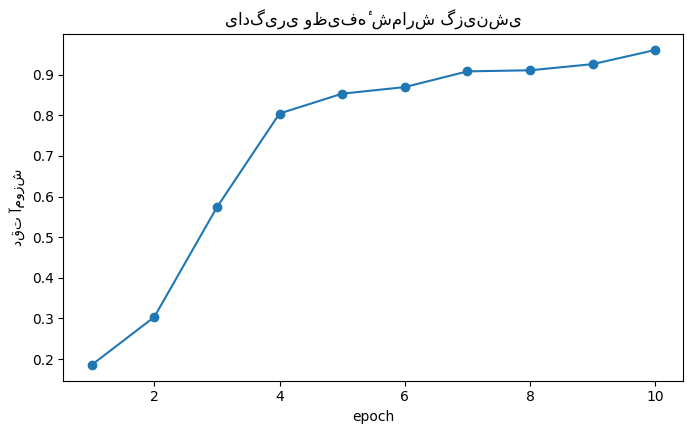

In [28]:
class SumTransformer(nn.Module):
    def __init__(self, vocab=11, d_model=64, n_heads=4, n_blocks=2, d_ff=128, n_classes=13):
        super().__init__()
        self.emb = nn.Embedding(vocab, d_model)
        self.blocks = nn.ModuleList(
            [TransformerBlock(d_model, n_heads, d_ff) for _ in range(n_blocks)])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, n_classes)

    def forward(self, x):
        h = self.emb(x)                       # (B, T, D)
        for blk in self.blocks:
            h, _ = blk(h)
        h = self.ln_f(h)
        return self.head(h[:, 0])             # logits از توکن ویژه (موقعیت ۰)

def make_count_data(n, seq_len, seed):
    rng = np.random.default_rng(seed)
    X = rng.integers(0, 10, size=(n, seq_len))
    y = (X >= 5).sum(1)                       # تعداد ارقام >= 5
    X_in = np.hstack([np.full((n, 1), 10), X])   # توکن ویژه = 10 در ابتدا
    return torch.tensor(X_in, dtype=torch.long), torch.tensor(y, dtype=torch.long)

X6, y6 = make_count_data(5000, 12, SEED)
n_train = 4500
X6_tr, y6_tr, X6_te, y6_te = X6[:n_train], y6[:n_train], X6[n_train:], y6[n_train:]

torch.manual_seed(SEED)
model_t = SumTransformer()
opt = torch.optim.Adam(model_t.parameters(), lr=3e-4)
lossf = nn.CrossEntropyLoss()
acc_hist = []
for ep in range(10):
    model_t.train()
    perm = torch.randperm(n_train)
    correct, tot, losses = 0, 0, []
    for i in range(0, n_train, 128):
        b = perm[i:i+128]
        opt.zero_grad()
        logits = model_t(X6_tr[b])
        loss = lossf(logits, y6_tr[b])
        loss.backward(); opt.step()
        losses.append(loss.item())
        correct += (logits.argmax(1) == y6_tr[b]).sum().item(); tot += len(b)
    acc_hist.append(correct / tot)
    print(f"epoch {ep+1}: loss={np.mean(losses):.4f} | دقت آموزش: {correct/tot:.4f}")

model_t.eval()
with torch.no_grad():
    pred = model_t(X6_te).argmax(1)
test_acc = (pred == y6_te).float().mean().item()
pm1_acc = ((pred - y6_te).abs() <= 1).float().mean().item()
print(f"دقت آزمون (exact): {test_acc:.4f} | دقت تا خطای یک: {pm1_acc:.4f}")
plt.plot(range(1, 11), acc_hist, 'o-'); plt.xlabel('epoch'); plt.ylabel('دقت آموزش')
plt.title('یادگیری وظیفهٔ selective counting'); plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

**۶-د) (بخش اختیاری؛ نمرهٔ اضافه تا ۵)** وزن‌های توجه سر اولِ بلوک اول را برای یک نمونهٔ آزمون به‌صورت heatmap رسم کنید و تفسیر کنید: مدل به کدام توکن‌ها (مثلاً توکن‌های با مقدار بزرگ) توجه بیشتری دارد؟

</div>

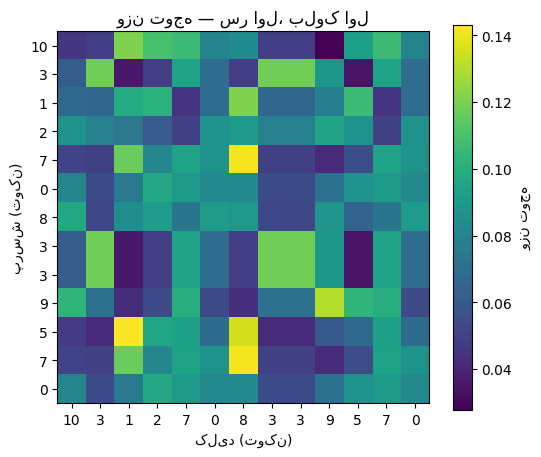

توکن ویژه در موقعیت ۰ است؛ سطر ۰ نشان می‌دهد توکن پیش‌پرس به کدام ارقام نگاه می‌کند.


In [29]:
# گرفتن وزن توجه سر اول بلوک اول برای یک نمونه
model_t.eval()
with torch.no_grad():
    h = model_t.emb(X6_te[:1])
    _, w = model_t.blocks[0].mha(model_t.blocks[0].ln1(h))
attn = w[0, 0].numpy()   # (T, T) برای سر اولِ نمونهٔ اول
plt.figure(figsize=(6, 5))
plt.imshow(attn, cmap='viridis')
plt.colorbar(label='وزن توجه')
seq = X6_te[0].numpy()
plt.xticks(range(len(seq)), [str(t) for t in seq])
plt.yticks(range(len(seq)), [str(t) for t in seq])
plt.xlabel('کلید (توکن)')
plt.ylabel('پرسش (توکن)')
plt.title('وزن توجه — سر اول، بلوک اول')
plt.show()
print("توکن ویژه در موقعیت ۰ است؛ سطر ۰ نشان می‌دهد توکن پیش‌پرس به کدام ارقام نگاه می‌کند.")

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

**تفسیر نمونه:** در این وظیفهٔ «selective counting»، انتظار می‌رود سطر توکن [CLS] (سطر ۰) به ارقام ⁦$\ge 5$⁩ (یا حتی فقط ⁦$5,6,7,8,9$⁩) وزن توجه بیشتری بدهد و به ارقام کوچک کمتر — دقیقاً همان الگویی که یک «threshold detector» یاد می‌گیرد. سرهای مختلف می‌توانند آستانه‌های متفاوتی بیاموزند و رأی‌گیری نهایی شمارش را بسازد. هر الگوی معنادار و مستند که با نقشهٔ حرارتی هم‌خوان باشد پذیرفته است.

</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.9; direction: rtl; text-align: right;">

---

<div dir="rtl" align="center">

**پایان آزمون عملی — موفق باشید**

</div>

</div>